In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import load_and_prep_data, run_validation_loop, HawkesModel
from src import plot_user_timeline, analyze_user_intensity, plot_parameter_distributions

In [3]:
sequences = load_and_prep_data('data/raw/retail_data.csv')
factory_reg = lambda p: HawkesModel(baseline_model=p, penalty_weight=50.0)

df_results = run_validation_loop(sequences, model_factory=factory_reg, label="Regularized", min_events=20)

Running 'Regularized': N=107


100%|██████████| 107/107 [00:00<00:00, 135.14it/s]


Hawkes Win Rate: 72.90%
Avg RMSE Improvement: -3.77%


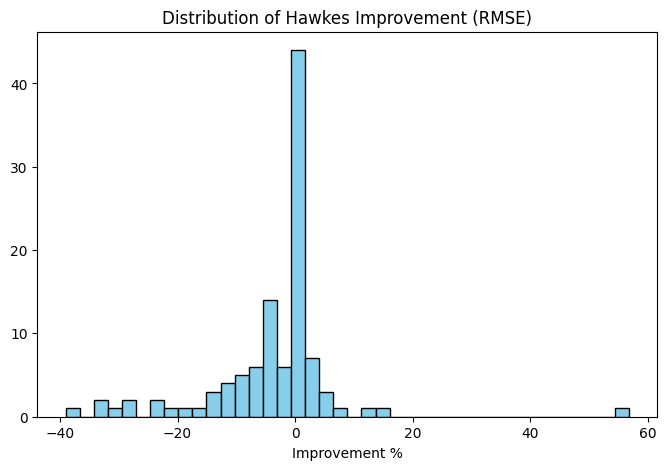

In [4]:
print(f"Hawkes Win Rate: {df_results['win_ll'].mean():.2%}")
print(f"Avg RMSE Improvement: {df_results['imp_rmse'].mean():.2f}%")

plt.figure(figsize=(8, 5))
plt.hist(df_results['imp_rmse'], bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Hawkes Improvement (RMSE)')
plt.xlabel('Improvement %')
plt.show()

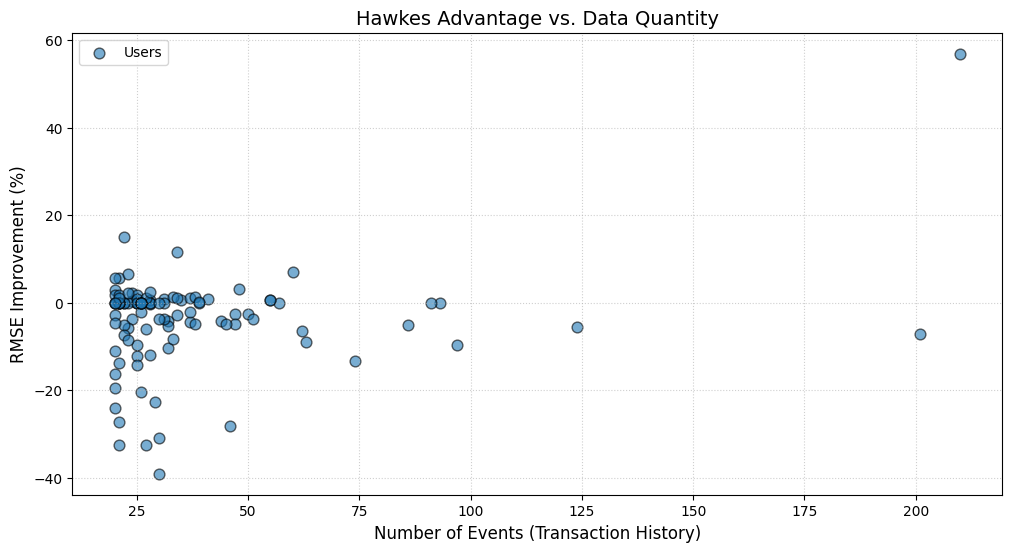

In [5]:
# Настраиваем размер
plt.figure(figsize=(12, 6))

plt.scatter(df_results['events'], df_results['imp_rmse'], 
            alpha=0.6, s=60, edgecolors='black', label='Users')


plt.title('Hawkes Advantage vs. Data Quantity', fontsize=14)
plt.xlabel('Number of Events (Transaction History)', fontsize=12)
plt.ylabel('RMSE Improvement (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

Winner ID: 12748.0 (Imp: 56.9%)
Loser ID:  15159.0 (Imp: -39.1%)


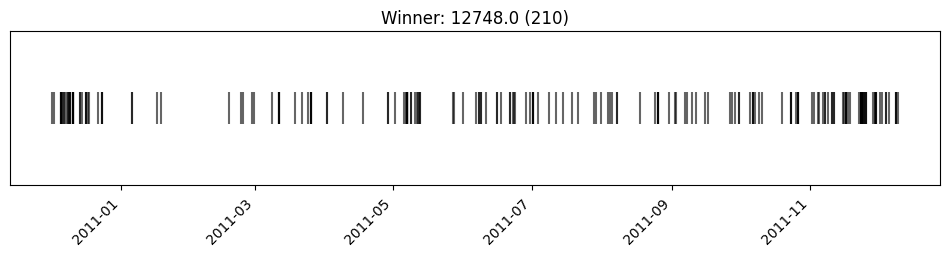

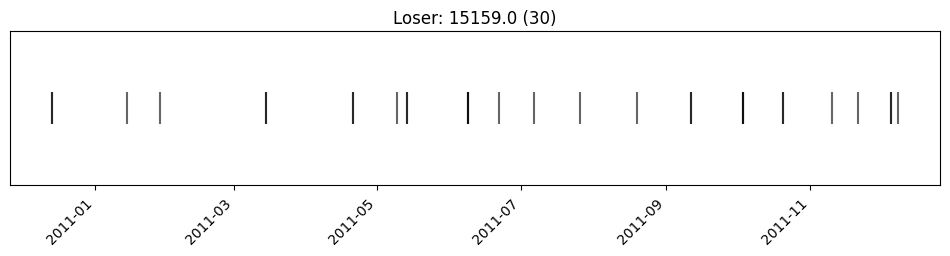

In [6]:
winners = df_results[df_results['imp_rmse'] > 10].sort_values('imp_rmse', ascending=False)
losers = df_results[df_results['imp_rmse'] < -10].sort_values('imp_rmse')

winner_id, loser_id = winners.iloc[0]['user_id'], losers.iloc[0]['user_id']

print(f"Winner ID: {winner_id} (Imp: {winners.iloc[0]['imp_rmse']:.1f}%)")
print(f"Loser ID:  {loser_id} (Imp: {losers.iloc[0]['imp_rmse']:.1f}%)")

plot_user_timeline(sequences, winner_id, title="Winner")
plot_user_timeline(sequences, loser_id, title="Loser")

/Users/amosh239/repo/mkn/Hawk's proccess/src/visualization.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grid = pd.date_range(train[0], test[-1], freq='1H')


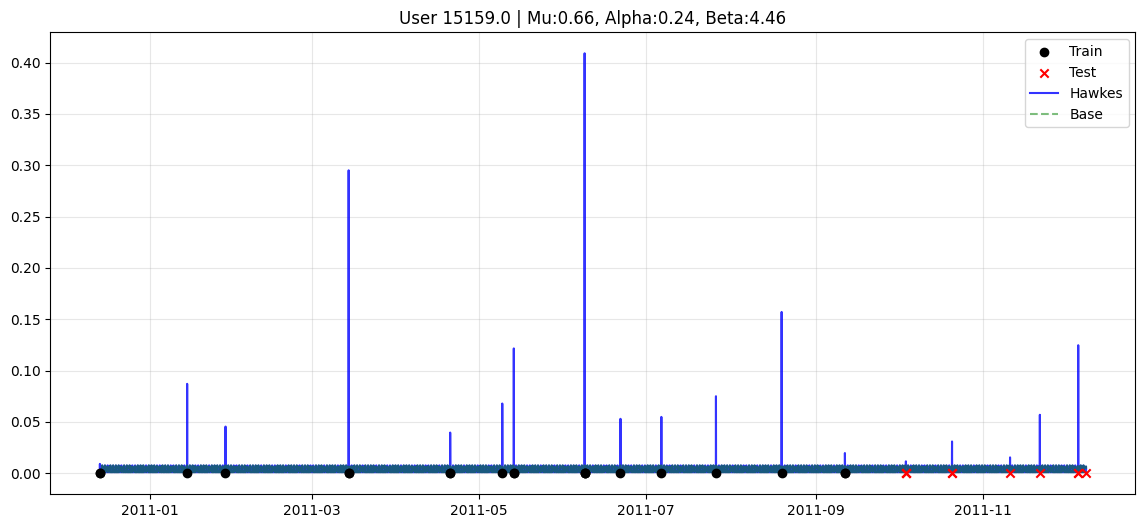

In [7]:
factory_reg = lambda p: HawkesModel(baseline_model=p, penalty_weight=50.0)
analyze_user_intensity(sequences, loser_id, factory_reg, ratio=0.8)

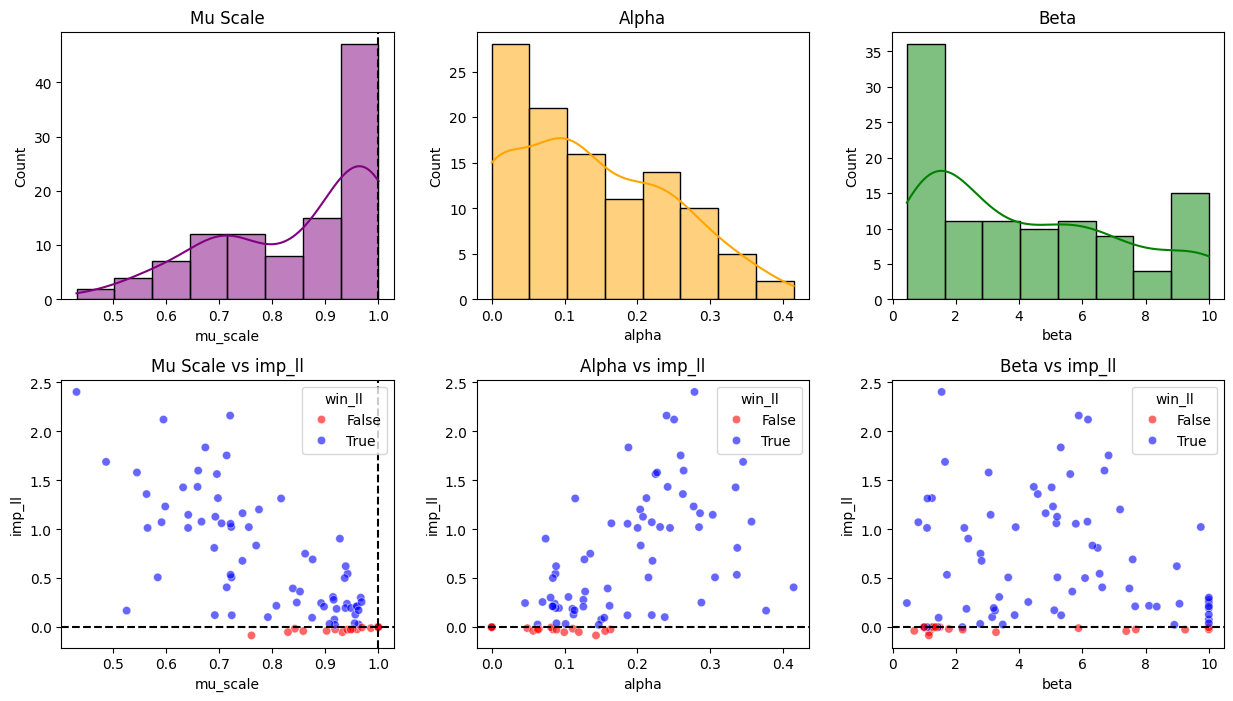

              mean       std       min       50%        max
mu_scale  0.847797  0.150484  0.431171  0.914819   1.000432
alpha     0.133735  0.109547  0.000001  0.113688   0.414482
beta      4.270054  3.097416  0.450453  3.370907  10.000000


In [8]:
plot_parameter_distributions(df_results)

In [16]:
sequences = load_and_prep_data('data/raw/retail_data.csv')

class ScaledPoisson:
    def __init__(self, baseline):
        self.baseline = baseline
        self.mu = 1.0
        self.kernel = 'scaled'
        self.penalty_weight = 0

    def fit(self, times):
        T = (times[-1] - times[0]).total_seconds() / 3600
        if T < 1e-3: T = 1e-3
        
        # Грубая оценка интеграла бейзлайна для MLE
        t_check = [times[0], times[len(times)//2], times[-1]]
        base_avg = np.mean([self.baseline.get_intensity(t) for t in t_check])
        integral = base_avg * T
        
        self.mu = len(times) / integral if integral > 0 else 1.0
        return self

    @property
    def params(self):
        return [self.mu, 0.0, 1.0, 1.0]

    def get_intensity(self, t, history=None):
        return self.baseline.get_intensity(t) * self.mu

    def nll(self, times, T_max):
        return 0.0 

In [17]:
print(">>> Running Scaled Poisson...")
factory_scaled = lambda p: ScaledPoisson(p)
df_scaled = run_validation_loop(sequences, factory_scaled, label="ScaledOnly", min_events=30)

print("\n>>> Running Full Hawkes...")
factory_hawkes = lambda p: HawkesModel(p, penalty_weight=20.0, kernel='exp')
df_hawkes = run_validation_loop(sequences, factory_hawkes, label="FullHawkes", min_events=30)



>>> Running Scaled Poisson...
Running 'ScaledOnly': N=46


100%|██████████| 46/46 [00:00<00:00, 2177.43it/s]



>>> Running Full Hawkes...
Running 'FullHawkes': N=46


100%|██████████| 46/46 [00:00<00:00, 102.46it/s]


>>> 1/2 Running Scaled Poisson (Corrected)...
Running 'Scaled': N=46


100%|██████████| 46/46 [00:00<00:00, 1633.57it/s]



>>> 2/2 Running Full Hawkes...
Running 'Hawkes': N=46


100%|██████████| 46/46 [00:00<00:00, 102.09it/s]



Avg LL Gain: -0.1903
Win Rate (Hawkes > Scaled): 32.6%


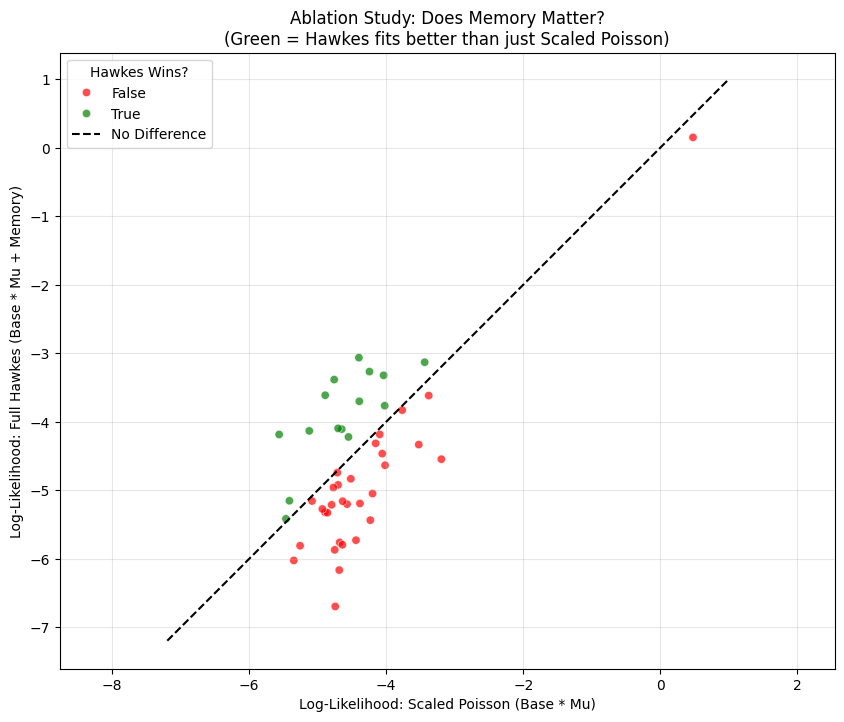

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import run_validation_loop, HawkesExp

# --- 1. CORRECTED SCALED POISSON ---
class ScaledPoisson:
    def __init__(self, baseline):
        self.baseline = baseline
        self.mu = 1.0
        self.kernel = 'scaled'
        self.penalty_weight = 0

    def fit(self, times):
        T = (times[-1] - times[0]).total_seconds() / 3600
        if T < 1e-3: T = 1e-3
        
        # Считаем интеграл бейзлайна честно
        # (Усредняем интенсивность в нескольких точках для оценки)
        check_points = np.linspace(times[0].timestamp(), times[-1].timestamp(), 10)
        check_dates = pd.to_datetime(check_points, unit='s')
        base_rates = [self.baseline.get_intensity(t) for t in check_dates]
        self.base_integral = np.mean(base_rates) * T
        
        # MLE для mu: N / Integral
        self.mu = len(times) / self.base_integral if self.base_integral > 0 else 1.0
        return self

    @property
    def params(self):
        return [self.mu, 0.0, 1.0, 1.0]

    def get_intensity(self, t, history=None):
        return self.baseline.get_intensity(t) * self.mu

    def nll(self, times, T_max):
        # Честный NLL = -(Sum(log(lambda)) - Integral(lambda))
        # lambda(t) = mu * base(t)
        # log(lambda) = log(mu) + log(base)
        
        log_mu = np.log(self.mu) if self.mu > 1e-9 else -10
        
        # Сумма логарифмов бейзлайна (дорого, но честно)
        log_base_sum = 0
        for t in times:
            lb = self.baseline.get_intensity(t)
            log_base_sum += np.log(lb) if lb > 1e-9 else -10
            
        term1 = len(times) * log_mu + log_base_sum
        term2 = self.mu * self.base_integral # Интеграл модели
        
        return -(term1 - term2)

# --- 2. RUN EXPERIMENT ---
print(">>> 1/2 Running Scaled Poisson (Corrected)...")
factory_scaled = lambda p: ScaledPoisson(p)
df_scaled = run_validation_loop(sequences, factory_scaled, label="Scaled", min_events=30)

print("\n>>> 2/2 Running Full Hawkes...")
factory_hawkes = lambda p: HawkesModel(p, penalty_weight=20.0, kernel='exp')
df_hawkes = run_validation_loop(sequences, factory_hawkes, label="Hawkes", min_events=30)

# --- 3. MERGE & VISUALIZE ---
# Объединяем результаты
key_col = 'll_model' if 'll_model' in df_scaled.columns else 'll_challenger' # Защита от версий
df_comp = pd.merge(df_scaled[['user_id', key_col]], 
                   df_hawkes[['user_id', key_col]], 
                   on='user_id', suffixes=('_scaled', '_hawkes'))

# Считаем выгоду: (LL_Hawkes - LL_Scaled)
df_comp['gain'] = df_comp[f'{key_col}_hawkes'] - df_comp[f'{key_col}_scaled']
avg_gain = df_comp['gain'].mean()
win_rate = (df_comp['gain'] > 0).mean()

print(f"\nAvg LL Gain: {avg_gain:.4f}")
print(f"Win Rate (Hawkes > Scaled): {win_rate:.1%}")

# --- КРАСИВЫЙ ГРАФИК ---
plt.figure(figsize=(10, 8))

# 1. Scatter Plot
sns.scatterplot(data=df_comp, x=f'{key_col}_scaled', y=f'{key_col}_hawkes', 
                hue=df_comp['gain'] > 0, palette={True: 'green', False: 'red'}, alpha=0.7)

# 2. Diagonal Line (Equality)
min_val = min(df_comp[f'{key_col}_scaled'].min(), df_comp[f'{key_col}_hawkes'].min()) - 0.5
max_val = max(df_comp[f'{key_col}_scaled'].max(), df_comp[f'{key_col}_hawkes'].max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='No Difference')

plt.title(f"Ablation Study: Does Memory Matter?\n(Green = Hawkes fits better than just Scaled Poisson)")
plt.xlabel('Log-Likelihood: Scaled Poisson (Base * Mu)')
plt.ylabel('Log-Likelihood: Full Hawkes (Base * Mu + Memory)')
plt.legend(title='Hawkes Wins?')
plt.grid(True, alpha=0.3)
plt.axis('equal') # Чтобы диагональ была под 45 градусов
plt.show()